In [12]:
import os

# force working directory to repo root
notebook_dir = os.path.dirname(os.path.abspath("day02_exploration.ipynb"))
root_dir = os.path.dirname(notebook_dir)
os.chdir(root_dir)

print(f"working directory set to: {os.getcwd()}")

working directory set to: c:\Users\Subramani Mokkala\Desktop\arc-agi3-research


In [5]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from dotenv import load_dotenv
import arc_agi

load_dotenv()

arc = arc_agi.Arcade(arc_api_key=os.getenv("ARC_API_KEY"))
envs = arc.get_environments()

print("connected, environments loaded:", len(envs))

INFO:arc_agi.scorecard:Initialized ScorecardManager with idle_for=0:15:00 and max_open_for=3 days, 0:00:00
2026-06-13 16:23:31 | INFO | Successfully fetched 25 environment(s) from API
connected, environments loaded: 25


In [13]:
import arc_agi
from dotenv import load_dotenv
load_dotenv()

arc = arc_agi.Arcade(arc_api_key=__import__('os').getenv("ARC_API_KEY"))

methods = [m for m in dir(arc) if not m.startswith('_')]
print("Available methods on Arcade:")
for m in methods:
    print(f"  → {m}")

INFO:arc_agi.scorecard:Initialized ScorecardManager with idle_for=0:15:00 and max_open_for=3 days, 0:00:00
2026-06-12 15:54:24 | INFO | Successfully fetched 25 environment(s) from API
Available methods on Arcade:
  → arc_api_key
  → arc_base_url
  → available_environments
  → close_scorecard
  → create_scorecard
  → environments_dir
  → get_environments
  → get_scorecard
  → listen_and_serve
  → logger
  → make
  → on_scorecard_close
  → open_scorecard
  → operation_mode
  → recordings_dir
  → scorecard_manager


In [14]:
envs = arc.get_environments()
print(f"Total environments available: {len(envs)}")
print("\nEnvironments List:")
for env in envs:
    print(f"  → {env}")

print("First Environment Details:")
first = envs[0]
print(f"Type: {type(first)}")
print(f"Attributes: {[a for a in dir(first) if not a.startswith('_')]}")

Total environments available: 25

Environments List:
  → game_id='ka59-38d34dbb' title='KA59' default_fps=5 tags=['keyboard_click'] private_tags=None level_tags=None baseline_actions=[28, 109, 51, 51, 33, 132, 326] date_downloaded=datetime.datetime(2026, 6, 12, 10, 24, 24, 864043, tzinfo=datetime.timezone.utc) class_name='Ka59' local_dir=None
  → game_id='g50t-5849a774' title='G50T' default_fps=5 tags=['keyboard'] private_tags=None level_tags=None baseline_actions=[78, 175, 179, 230, 96, 54, 67] date_downloaded=datetime.datetime(2026, 6, 12, 10, 24, 24, 864073, tzinfo=datetime.timezone.utc) class_name='G50t' local_dir=None
  → game_id='dc22-fdcac232' title='DC22' default_fps=5 tags=['keyboard_click'] private_tags=None level_tags=None baseline_actions=[59, 102, 67, 98, 324, 578] date_downloaded=datetime.datetime(2026, 6, 12, 10, 24, 24, 864084, tzinfo=datetime.timezone.utc) class_name='Dc22' local_dir=None
  → game_id='sk48-d8078629' title='SK48' default_fps=5 tags=['keyboard_click'] pr

In [16]:
# LS20

target = None
for env in envs:
    if env.title == "LS20":
        target = env
        break

print(f"Selected environment: {target.title}")
print(f"Game ID: {target.game_id}")
print(f"Tags: {target.tags}")
print(f"Baseline actions per level: {target.baseline_actions}")
print(f"Total levels: {len(target.baseline_actions)}")

print("\nOpening Scorecard")
try:
    scorecard = arc.open_scorecard(game_id=target.game_id)
    print(f"Scorecard opened!")
    print(f"Scorecard attributes: {[a for a in dir(scorecard) if not a.startswith('_')]}")
except Exception as e:
    print(f"Error: {e}")
    # Try with make instead
    print("\nTrying arc.make()...")
    env_instance = arc.make(target.game_id)
    print(f"Environment created!")
    print(f"Type: {type(env_instance)}")
    print(f"Attributes: {[a for a in dir(env_instance) if not a.startswith('_')]}")

Selected environment: LS20
Game ID: ls20-9607627b
Tags: ['keyboard']
Baseline actions per level: [22, 123, 73, 84, 96, 192, 186]
Total levels: 7

Opening Scorecard
Error: Arcade.open_scorecard() got an unexpected keyword argument 'game_id'

Trying arc.make()...
2026-06-12 16:00:40 | INFO | Created new scorecard: 858b5bbd-0ea8-4305-a453-49ec90aa8c8b
2026-06-12 16:00:44 | INFO | Successfully fetched metadata for game ls20
2026-06-12 16:00:50 | INFO | Successfully downloaded game ls20 (version: 9607627b) to environment_files\ls20\9607627b
2026-06-12 16:00:50 | INFO | Successfully loaded game class Ls20 from environment_files\ls20\9607627b\ls20.py
Environment created!
Type: <class 'arc_agi.local_wrapper.LocalEnvironmentWrapper'>
Attributes: ['action_space', 'environment_info', 'include_frame_data', 'info', 'logger', 'observation_space', 'recordings_dir', 'renderer', 'reset', 'save_recording', 'scorecard_id', 'scorecard_manager', 'step']


In [17]:
env_instance = arc.make(target.game_id)

print("Action Space")
print(type(env_instance.action_space))
print(env_instance.action_space)

print("\nObservation Space")
print(type(env_instance.observation_space))
print(env_instance.observation_space)

print("\nResetting Environment")
obs = env_instance.reset()
print(type(obs))
print(obs)

print("\nEnvironment Info")
info = env_instance.info
print(type(info))
print(info)

2026-06-12 16:02:22 | INFO | Successfully fetched metadata for game ls20
Action Space
<class 'list'>
[<GameAction.ACTION1: 1>, <GameAction.ACTION2: 2>, <GameAction.ACTION3: 3>, <GameAction.ACTION4: 4>]

Observation Space
<class 'arcengine.enums.FrameDataRaw'>
{
  "game_id": "ls20-9607627b",
  "state": "NOT_FINISHED",
  "levels_completed": 0,
  "win_levels": 7,
  "action_input": {
    "id": 0,
    "data": {},
    "reasoning": null
  },
  "guid": "0f2f13df-7ba9-41e9-bb0f-b7661500fad2",
  "full_reset": true,
  "available_actions": [
    1,
    2,
    3,
    4
  ]
}

Resetting Environment
<class 'arcengine.enums.FrameDataRaw'>
{
  "game_id": "ls20-9607627b",
  "state": "NOT_FINISHED",
  "levels_completed": 0,
  "win_levels": 7,
  "action_input": {
    "id": 0,
    "data": {},
    "reasoning": null
  },
  "guid": "0f2f13df-7ba9-41e9-bb0f-b7661500fad2",
  "full_reset": true,
  "available_actions": [
    1,
    2,
    3,
    4
  ]
}

Environment Info
<class 'arc_agi.models.EnvironmentInfo'>
g

In [19]:
import json

obs = env_instance.reset()

obs_dict = json.loads(obs.json()) if hasattr(obs, 'json') else obs.__dict__

print("Full observation keys:")
for key in obs_dict.keys():
    value = obs_dict[key]
    print(f"  {key}: {type(value).__name__} = {str(value)[:100]}")

print("\nTaking one action and observing result")
result = env_instance.step(1)
print(f"Result type: {type(result)}")
print(f"Result: {str(result)[:500]}")

Full observation keys:
  game_id: str = ls20-9607627b
  state: str = NOT_FINISHED
  levels_completed: int = 0
  win_levels: int = 7
  action_input: dict = {'id': 0, 'data': {}, 'reasoning': None}
  guid: str = 0f2f13df-7ba9-41e9-bb0f-b7661500fad2
  full_reset: bool = True
  available_actions: list = [1, 2, 3, 4]

Taking one action and observing result
Result type: <class 'arcengine.enums.FrameDataRaw'>
Result: {
  "game_id": "ls20-9607627b",
  "state": "NOT_FINISHED",
  "levels_completed": 0,
  "win_levels": 7,
  "action_input": {
    "id": 1,
    "data": {},
    "reasoning": null
  },
  "guid": "0f2f13df-7ba9-41e9-bb0f-b7661500fad2",
  "full_reset": false,
  "available_actions": [
    1,
    2,
    3,
    4
  ]
}


C:\Users\Subramani Mokkala\AppData\Local\Temp\ipykernel_25056\2264196043.py:5: PydanticDeprecatedSince20: The `json` method is deprecated; use `model_dump_json` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.13/migration/
  obs_dict = json.loads(obs.json()) if hasattr(obs, 'json') else obs.__dict__


In [20]:
obs = env_instance.reset()

print("obs type:", type(obs))
print("has frame_data:", hasattr(obs, 'frame_data'))
print("has image:", hasattr(obs, 'image'))
print("has pixels:", hasattr(obs, 'pixels'))
print("has data:", hasattr(obs, 'data'))

print("\nAll attributes and values:")
for key, value in obs:
    print(f"  {key} ({type(value).__name__}): {str(value)[:200]}")

print("\nenv_instance.include_frame_data:", env_instance.include_frame_data)

obs type: <class 'arcengine.enums.FrameDataRaw'>
has frame_data: False
has image: False
has pixels: False
has data: False

All attributes and values:
  game_id (str): ls20-9607627b
  state (GameState): GameState.NOT_FINISHED
  levels_completed (int): 0
  win_levels (int): 7
  action_input (ActionInput): id=<GameAction.RESET: 0> data={} reasoning=None
  guid (str): 0f2f13df-7ba9-41e9-bb0f-b7661500fad2
  full_reset (bool): False
  available_actions (list): [1, 2, 3, 4]

env_instance.include_frame_data: True


In [21]:
import arc_agi
help(arc_agi.Arcade.make)

Help on function make in module arc_agi.base:

make(
    self,
    game_id: str,
    seed: int = 0,
    scorecard_id: Optional[str] = None,
    save_recording: bool = False,
    include_frame_data: bool = True,
    render_mode: Optional[str] = None,
    renderer: Optional[Callable[[int, FrameDataRaw], None]] = None
) -> Optional[EnvironmentWrapper]
    Make (download and prepare) an environment.

    Args:
        game_id: Game identifier in format 'ls20' or 'ls20-1234abcd'.
            The first 4 characters are the game_id, everything after '-' is the version.
        scorecard_id: Optional scorecard ID for tracking runs. If not provided,
            a new scorecard will be created and stored for subsequent calls.
        save_recording: Whether to save recordings to JSONL file.
        render_mode: Optional render mode string ("human", "terminal"). If provided,
            creates a renderer callable automatically.
        renderer: Optional callable that accepts FrameDataRaw and pe

In [22]:
import os
import arc_agi
from dotenv import load_dotenv
load_dotenv()

arc = arc_agi.Arcade(arc_api_key=os.getenv("ARC_API_KEY"))

env_instance = arc.make(
    game_id="ls20",
    render_mode="terminal",
    save_recording=True
)

obs = env_instance.reset()

print("state:", obs.state)
print("levels_completed:", obs.levels_completed)
print("win_levels:", obs.win_levels)
print("available_actions:", obs.available_actions)

INFO:arc_agi.scorecard:Initialized ScorecardManager with idle_for=0:15:00 and max_open_for=3 days, 0:00:00
2026-06-12 16:06:18 | INFO | Successfully fetched 25 environment(s) from API
2026-06-12 16:06:18 | INFO | Created new scorecard: 4778e0c1-7247-4f52-ade8-6d53761ec8e2
2026-06-12 16:06:19 | INFO | Successfully fetched metadata for game ls20
2026-06-12 16:06:19 | INFO | Recording to recordings\4778e0c1-7247-4f52-ade8-6d53761ec8e2\ls20-9607627b-97b1aee3-1778-4fc4-9d2e-38ef8163c749.jsonl
Step: 1 - State: NOT_FINISHED

████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
█████████████████████████████████████████████████████████████████████████████████████████

Step: 2 - State: NOT_FINISHED

████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
██████████████████████████████████████████████████████████████████

state: GameState.NOT_FINISHED
levels_completed: 0
win_levels: 7
available_actions: [1, 2, 3, 4]


In [23]:
import os
import random
import arc_agi
from dotenv import load_dotenv
load_dotenv()

arc = arc_agi.Arcade(arc_api_key=os.getenv("ARC_API_KEY"))

env = arc.make(
    game_id="ls20",
    save_recording=True
)

obs = env.reset()

step = 0
max_steps = 500

while obs.state.value == "NOT_FINISHED" and step < max_steps:
    action = random.choice(obs.available_actions)
    obs = env.step(action)
    step += 1

    if step % 50 == 0:
        print(f"step {step} | state: {obs.state.value} | levels completed: {obs.levels_completed}")

print(f"\nGame ended after {step} steps")
print(f"Final state: {obs.state.value}")
print(f"Levels completed: {obs.levels_completed} / {obs.win_levels}")

INFO:arc_agi.scorecard:Initialized ScorecardManager with idle_for=0:15:00 and max_open_for=3 days, 0:00:00
2026-06-12 16:07:15 | INFO | Successfully fetched 25 environment(s) from API
2026-06-12 16:07:15 | INFO | Created new scorecard: 484bb3d7-8e2d-4f2f-a4c2-33c34b4ea806
2026-06-12 16:07:17 | INFO | Successfully fetched metadata for game ls20
2026-06-12 16:07:17 | INFO | Recording to recordings\484bb3d7-8e2d-4f2f-a4c2-33c34b4ea806\ls20-9607627b-86c3c1d7-4ad4-45f6-bb12-e21be3a54e64.jsonl
step 50 | state: NOT_FINISHED | levels completed: 0
step 100 | state: NOT_FINISHED | levels completed: 0

Game ended after 137 steps
Final state: GAME_OVER
Levels completed: 0 / 7


In [24]:
import json
import os

recordings_dir = "recordings"
all_files = []
for root, dirs, files in os.walk(recordings_dir):
    for file in files:
        if file.endswith(".jsonl"):
            all_files.append(os.path.join(root, file))

latest = sorted(all_files)[-1]
print(f"Reading: {latest}")

frames = []
with open(latest, "r") as f:
    for line in f:
        frames.append(json.loads(line))

print(f"Total frames recorded: {len(frames)}")
print(f"\nFirst frame keys: {list(frames[0].keys())}")
print(f"\nFirst frame:")
print(json.dumps(frames[0], indent=2)[:1000])

Reading: recordings\484bb3d7-8e2d-4f2f-a4c2-33c34b4ea806\ls20-9607627b-86c3c1d7-4ad4-45f6-bb12-e21be3a54e64.jsonl
Total frames recorded: 139

First frame keys: ['timestamp', 'data']

First frame:
{
  "timestamp": "2026-06-12T10:37:17.251959+00:00",
  "data": {
    "game_id": "ls20-9607627b",
    "state": "NOT_FINISHED",
    "levels_completed": 0,
    "win_levels": 7,
    "action_input": {
      "id": "RESET",
      "data": {},
      "reasoning": null
    },
    "guid": "86c3c1d7-4ad4-45f6-bb12-e21be3a54e64",
    "full_reset": true,
    "available_actions": [
      1,
      2,
      3,
      4
    ],
    "frame": [
      [
        [
          5,
          5,
          5,
          5,
          4,
          4,
          4,
          4,
          4,
          4,
          4,
          4,
          4,
          4,
          4,
          4,
          4,
          4,
          4,
          4,
          4,
          4,
          4,
          4,
          4,
          4,
          4,
         

In [7]:
import os
os.makedirs("logs", exist_ok=True)
plt.savefig("logs/ls20_action_mapping.png", dpi=100)
print("saved")

saved


<Figure size 640x480 with 0 Axes>

In [8]:
import json
import numpy as np
import matplotlib.pyplot as plt

with open(latest, "r") as f:
    frames = [json.loads(line) for line in f]

first_frame = np.array(frames[0]["data"]["frame"]).squeeze()
last_frame = np.array(frames[-1]["data"]["frame"]).squeeze()

print(f"Frame shape after squeeze: {first_frame.shape}")
print(f"Unique color values: {np.unique(first_frame).tolist()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(first_frame, cmap="tab10", vmin=0, vmax=9)
axes[0].set_title("First Frame (after reset)")
axes[0].axis("off")

axes[1].imshow(last_frame, cmap="tab10", vmin=0, vmax=9)
axes[1].set_title("Last Frame (GAME_OVER)")
axes[1].axis("off")

plt.tight_layout()
plt.savefig("logs/ls20_first_last_frame.png", dpi=100)
plt.show()

NameError: name 'latest' is not defined

In [9]:
import os

os.makedirs("logs", exist_ok=True)
plt.savefig("logs/ls20_first_last_frame.png", dpi=100)
print("saved to logs/ls20_first_last_frame.png")

saved to logs/ls20_first_last_frame.png


<Figure size 640x480 with 0 Axes>

2026-06-13 16:26:22 | INFO | Successfully fetched metadata for game ls20


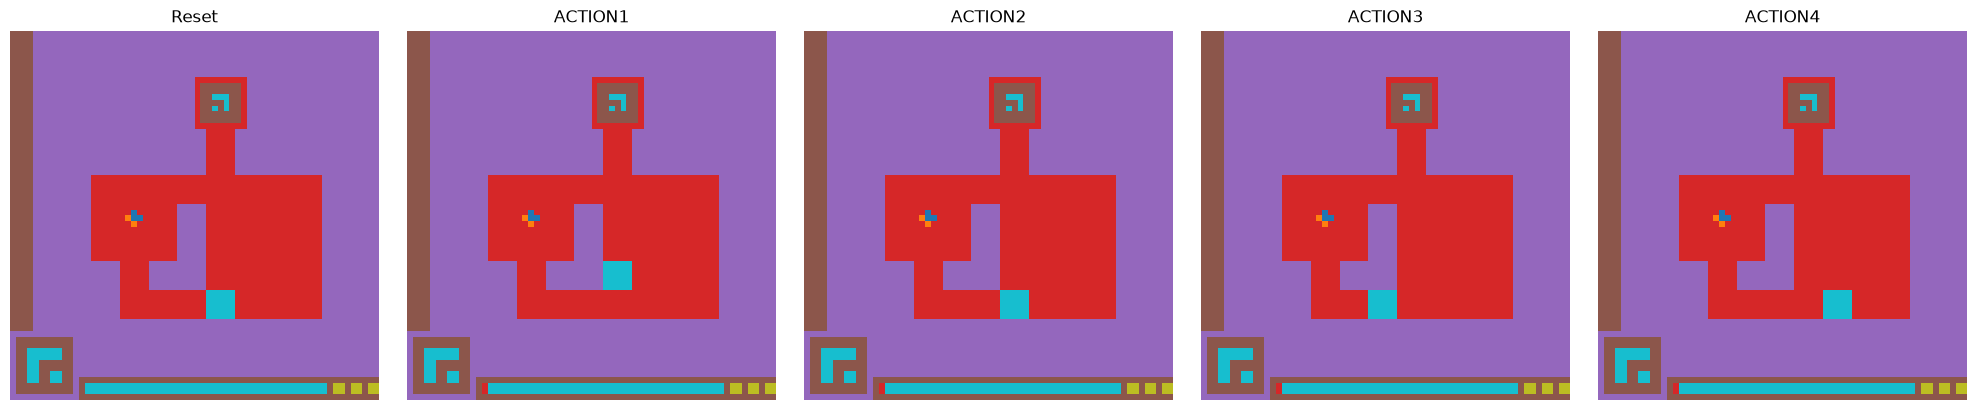

In [10]:
env = arc.make(game_id="ls20")

obs = env.reset()
first_frame = np.array(obs.frame).squeeze()

frames = {}
frames[0] = first_frame

for action in [1, 2, 3, 4]:
    env.reset()
    obs = env.step(action)
    frames[action] = np.array(obs.frame).squeeze()

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

axes[0].imshow(frames[0], cmap="tab10", vmin=0, vmax=9)
axes[0].set_title("Reset")
axes[0].axis("off")

for i, action in enumerate([1, 2, 3, 4]):
    axes[i+1].imshow(frames[action], cmap="tab10", vmin=0, vmax=9)
    axes[i+1].set_title(f"ACTION{action}")
    axes[i+1].axis("off")

plt.tight_layout()
plt.savefig("logs/ls20_action_mapping.png", dpi=100)
plt.show()

In [13]:
import os
import numpy as np
from dotenv import load_dotenv
import arc_agi

load_dotenv()

arc = arc_agi.Arcade(arc_api_key=os.getenv("ARC_API_KEY"))

env = arc.make(game_id="ls20", save_recording=True)

ACTION_UP = 1
ACTION_DOWN = 2
ACTION_LEFT = 3
ACTION_RIGHT = 4

def get_player_position(frame):
    frame = np.array(frame).squeeze()
    # cyan color index — player
    player_positions = np.argwhere(frame == 5)
    if len(player_positions) > 0:
        return player_positions.mean(axis=0)
    return None

def get_goal_position(frame):
    frame = np.array(frame).squeeze()
    # brown box at top — goal area
    goal_positions = np.argwhere(frame == 6)
    if len(goal_positions) > 0:
        return goal_positions.mean(axis=0)
    return None

obs = env.reset()
step = 0
max_steps = 500

print("starting directed agent")
print(f"player start: {get_player_position(obs.frame)}")
print(f"goal position: {get_goal_position(obs.frame)}")

while obs.state.value == "NOT_FINISHED" and step < max_steps:
    frame = np.array(obs.frame).squeeze()
    player = get_player_position(obs.frame)
    goal = get_goal_position(obs.frame)

    if player is None or goal is None:
        action = np.random.choice(obs.available_actions)
    else:
        row_diff = player[0] - goal[0]
        col_diff = player[1] - goal[1]

        if abs(row_diff) >= abs(col_diff):
            action = ACTION_UP if row_diff > 0 else ACTION_DOWN
        else:
            action = ACTION_LEFT if col_diff > 0 else ACTION_RIGHT

    obs = env.step(action)
    step += 1

    if step % 50 == 0:
        print(f"step {step} | state: {obs.state.value} | levels: {obs.levels_completed}")

print(f"\ngame ended after {step} steps")
print(f"final state: {obs.state.value}")
print(f"levels completed: {obs.levels_completed} / {obs.win_levels}")

INFO:arc_agi.scorecard:Initialized ScorecardManager with idle_for=0:15:00 and max_open_for=3 days, 0:00:00
2026-06-13 16:42:45 | INFO | Successfully fetched 25 environment(s) from API
2026-06-13 16:42:45 | INFO | Created new scorecard: 24ee01a2-4344-4d8a-bf6c-0e3defad230f
2026-06-13 16:42:46 | INFO | Successfully fetched metadata for game ls20
2026-06-13 16:42:46 | INFO | Recording to recordings\24ee01a2-4344-4d8a-bf6c-0e3defad230f\ls20-9607627b-f7deb1ff-5126-4457-bda7-5bb26e8a0d86.jsonl
2026-06-13 16:42:46 | INFO | Successfully loaded game class Ls20 from environment_files\ls20\9607627b\ls20.py
starting directed agent
player start: [38.92255125 14.93621868]
goal position: None
step 50 | state: NOT_FINISHED | levels: 0
step 100 | state: NOT_FINISHED | levels: 0

game ended after 130 steps
final state: GAME_OVER
levels completed: 0 / 7


In [14]:
obs = env.reset()
frame = np.array(obs.frame).squeeze()

print("unique color indices in frame:")
unique_colors = np.unique(frame)
print(unique_colors)

print("\npixel count per color:")
for color in unique_colors:
    count = np.sum(frame == color)
    print(f"  color {color}: {count} pixels")

unique color indices in frame:
[ 0  1  3  4  5  8  9 11 12]

pixel count per color:
  color 0: 3 pixels
  color 1: 2 pixels
  color 3: 892 pixels
  color 4: 2609 pixels
  color 5: 439 pixels
  color 8: 12 pixels
  color 9: 45 pixels
  color 11: 84 pixels
  color 12: 10 pixels


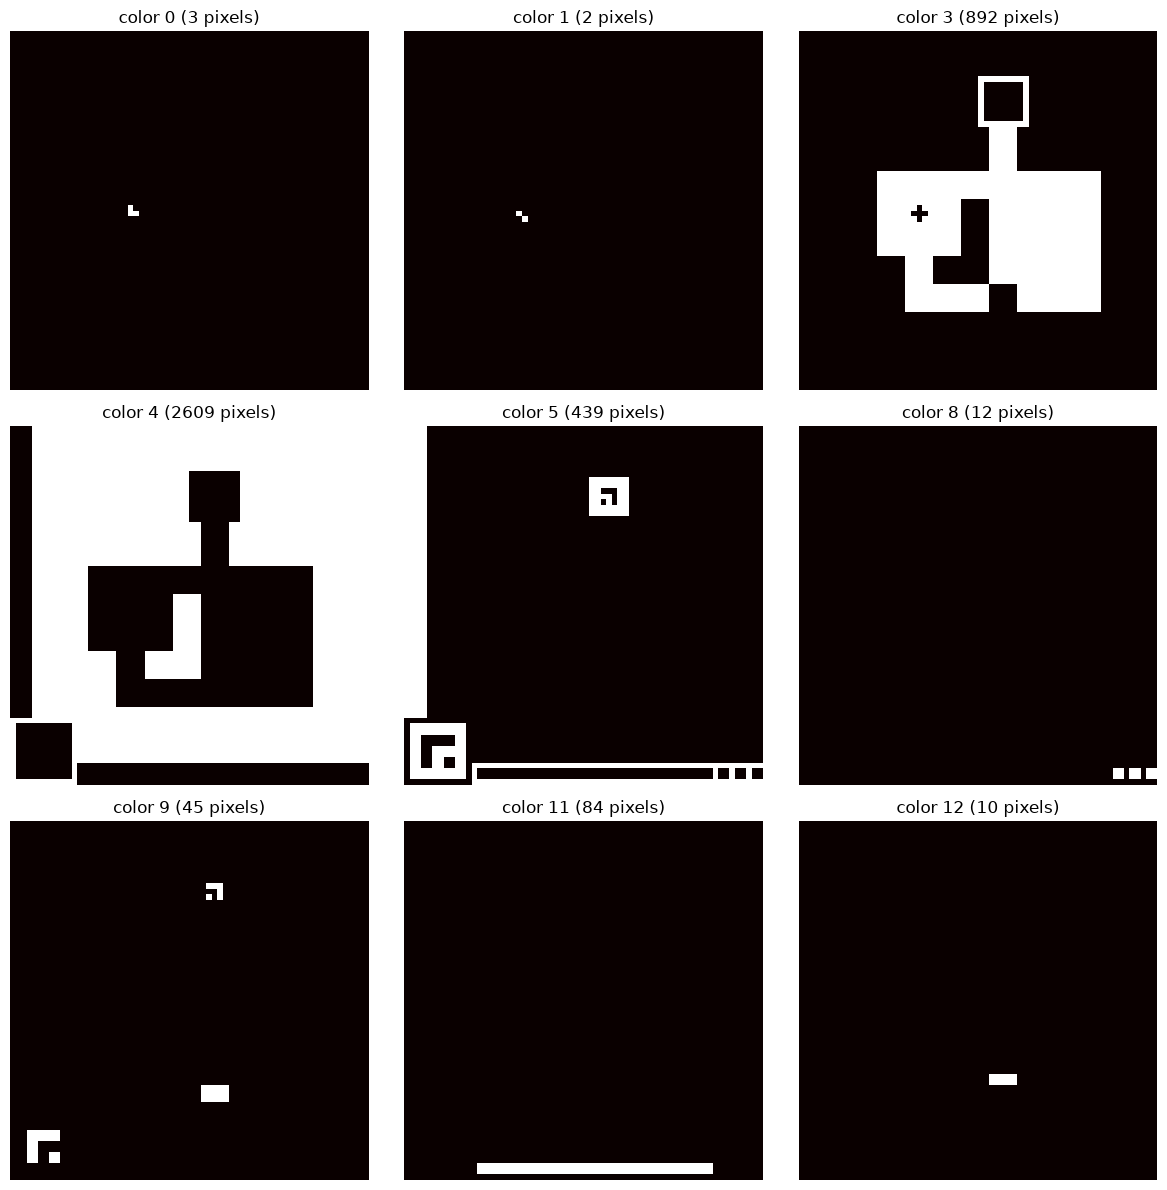

In [15]:
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
unique_colors = [0, 1, 3, 4, 5, 8, 9, 11, 12]

for idx, color in enumerate(unique_colors):
    ax = axes[idx // 3][idx % 3]
    mask = (frame == color).astype(float)
    ax.imshow(mask, cmap="hot")
    ax.set_title(f"color {color} ({np.sum(frame == color)} pixels)")
    ax.axis("off")

plt.tight_layout()
plt.savefig("logs/ls20_color_map.png", dpi=100)
plt.show()

In [16]:
def get_player_position(frame):
    frame = np.array(frame).squeeze()
    # player is where color 12 exists
    positions = np.argwhere(frame == 12)
    if len(positions) > 0:
        return positions.mean(axis=0)
    return None

def get_goal_position(frame):
    frame = np.array(frame).squeeze()
    # goal symbol is color 9 in the top half of frame only
    positions = np.argwhere(frame == 9)
    top_half = positions[positions[:, 0] < 32] if len(positions) > 0 else []
    if len(top_half) > 0:
        return np.array(top_half).mean(axis=0)
    return None

obs = env.reset()
print("player position:", get_player_position(obs.frame))
print("goal position:", get_goal_position(obs.frame))

player position: [45.5 36. ]
goal position: [11.83333333 36.16666667]


In [17]:
obs = env.reset()
step = 0
max_steps = 500

print("starting corrected directed agent")
print(f"player start: {get_player_position(obs.frame)}")
print(f"goal position: {get_goal_position(obs.frame)}")

while obs.state.value == "NOT_FINISHED" and step < max_steps:
    player = get_player_position(obs.frame)
    goal = get_goal_position(obs.frame)

    if player is None or goal is None:
        action = np.random.choice(obs.available_actions)
    else:
        row_diff = player[0] - goal[0]
        col_diff = player[1] - goal[1]

        if abs(row_diff) >= abs(col_diff):
            action = ACTION_UP if row_diff > 0 else ACTION_DOWN
        else:
            action = ACTION_LEFT if col_diff > 0 else ACTION_RIGHT

    obs = env.step(action)
    step += 1

    if step % 25 == 0:
        player = get_player_position(obs.frame)
        print(f"step {step} | levels: {obs.levels_completed} | player: {player}")

print(f"\ngame ended after {step} steps")
print(f"final state: {obs.state.value}")
print(f"levels completed: {obs.levels_completed} / {obs.win_levels}")

starting corrected directed agent
player start: [45.5 36. ]
goal position: [11.83333333 36.16666667]
step 25 | levels: 0 | player: [20.5 36. ]
step 50 | levels: 0 | player: [25.5 41. ]
step 75 | levels: 0 | player: [25.5 41. ]
step 100 | levels: 0 | player: [25.5 41. ]
step 125 | levels: 0 | player: [25.5 41. ]

game ended after 129 steps
final state: GAME_OVER
levels completed: 0 / 7


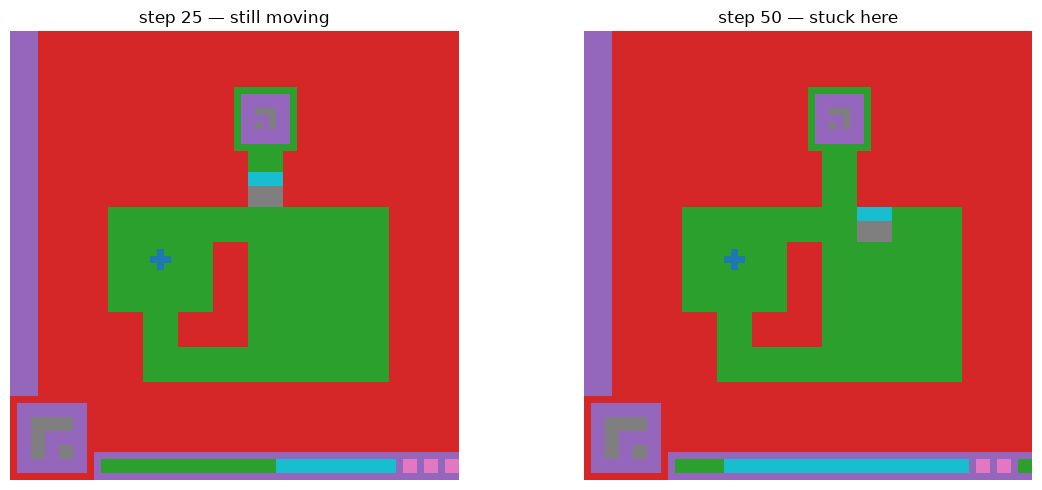

In [18]:
obs = env.reset()
step = 0
frame_at_25 = None
frame_at_50 = None

while obs.state.value == "NOT_FINISHED" and step < 60:
    player = get_player_position(obs.frame)
    goal = get_goal_position(obs.frame)

    if player is None or goal is None:
        action = np.random.choice(obs.available_actions)
    else:
        row_diff = player[0] - goal[0]
        col_diff = player[1] - goal[1]
        if abs(row_diff) >= abs(col_diff):
            action = ACTION_UP if row_diff > 0 else ACTION_DOWN
        else:
            action = ACTION_LEFT if col_diff > 0 else ACTION_RIGHT

    obs = env.step(action)
    step += 1

    if step == 25:
        frame_at_25 = np.array(obs.frame).squeeze()
    if step == 50:
        frame_at_50 = np.array(obs.frame).squeeze()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(frame_at_25, cmap="tab10", vmin=0, vmax=12)
axes[0].set_title("step 25 — still moving")
axes[0].axis("off")
axes[1].imshow(frame_at_50, cmap="tab10", vmin=0, vmax=12)
axes[1].set_title("step 50 — stuck here")
axes[1].axis("off")
plt.tight_layout()
plt.savefig("logs/ls20_stuck_analysis.png", dpi=100)
plt.show()

In [20]:
obs = env.reset()
step = 0
max_steps = 500
prev_player = None
stuck_count = 0
last_action = None

print("starting stuck-aware directed agent")

while obs.state.value == "NOT_FINISHED" and step < max_steps:
    player = get_player_position(obs.frame)
    goal = get_goal_position(obs.frame)

    if player is None or goal is None:
        action = np.random.choice(obs.available_actions)
    else:
        player = player[:2]
        goal = goal[:2]

        if prev_player is not None:
            if np.allclose(player, prev_player, atol=1.0):
                stuck_count += 1
            else:
                stuck_count = 0

        if stuck_count >= 3:
            other_actions = [a for a in obs.available_actions if a != last_action]
            action = np.random.choice(other_actions)
            stuck_count = 0
        else:
            row_diff = player[0] - goal[0]
            col_diff = player[1] - goal[1]
            if abs(row_diff) >= abs(col_diff):
                action = ACTION_UP if row_diff > 0 else ACTION_DOWN
            else:
                action = ACTION_LEFT if col_diff > 0 else ACTION_RIGHT

    prev_player = player[:2] if player is not None else None
    last_action = action
    obs = env.step(action)
    step += 1

    if step % 25 == 0:
        print(f"step {step} | levels: {obs.levels_completed} | player: {get_player_position(obs.frame)}")

print(f"\ngame ended after {step} steps")
print(f"final state: {obs.state.value}")
print(f"levels completed: {obs.levels_completed} / {obs.win_levels}")

starting stuck-aware directed agent
step 25 | levels: 0 | player: [20.5 36. ]
step 50 | levels: 0 | player: [25.5 41. ]
step 75 | levels: 0 | player: [25.5 41. ]
step 100 | levels: 0 | player: [20.5 36. ]
step 125 | levels: 0 | player: [15.5 36. ]

game ended after 129 steps
final state: GAME_OVER
levels completed: 0 / 7


In [21]:
# test: does the bar always run out at exactly the same step?
results = []

for trial in range(3):
    obs = env.reset()
    steps = 0
    while obs.state.value == "NOT_FINISHED":
        obs = env.step(1)  # just press up repeatedly
        steps += 1
    results.append(steps)
    print(f"trial {trial+1}: GAME_OVER at step {steps}")

print(f"\nstep counts: {results}")
print(f"consistent: {len(set(results)) == 1}")

KeyboardInterrupt: 